## Gamma ray burst

Define the needed functions

In [3]:
import numpy as np
import pandas as pd
import astropy.visualization.hist
from sklearn.cluster import MeanShift
from sklearn import preprocessing
import matplotlib.pyplot as plt
import requests


Load the data

In [4]:
# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt',verify=False)
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])


C:\Anaconda\Lib\site-packages\urllib3\connectionpool.py:1056: InsecureRequestWarning: Unverified HTTPS request is being made to host 'user-web.icecube.wisc.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(


Replace 999 with nan and format the data correctly

In [5]:
data_t = data.T

# Create DataFrame
df = pd.DataFrame(data_t, columns=names)
df = df.replace('-999', np.nan)  # In case -999 is a string

exclude_str = ['GRB_name', 'GRB_name_Fermi']
exclude_bool = ['GBM_located']
exclude_UTC = ['T0','T90_start']
all_columns = df.columns.tolist()
cols_to_numeric = [col for col in all_columns if col not in exclude_str + exclude_bool + exclude_UTC + ['T90_error','fluence_error','pos_error']]
df[cols_to_numeric] = df[cols_to_numeric].apply(pd.to_numeric, errors='coerce')
df[exclude_str] = df[exclude_str].astype('string')
df['GBM_located'] = df['GBM_located'].astype('bool')


Plot the distribution of the features to check which variable shows multimodality. T90 seems quite significant

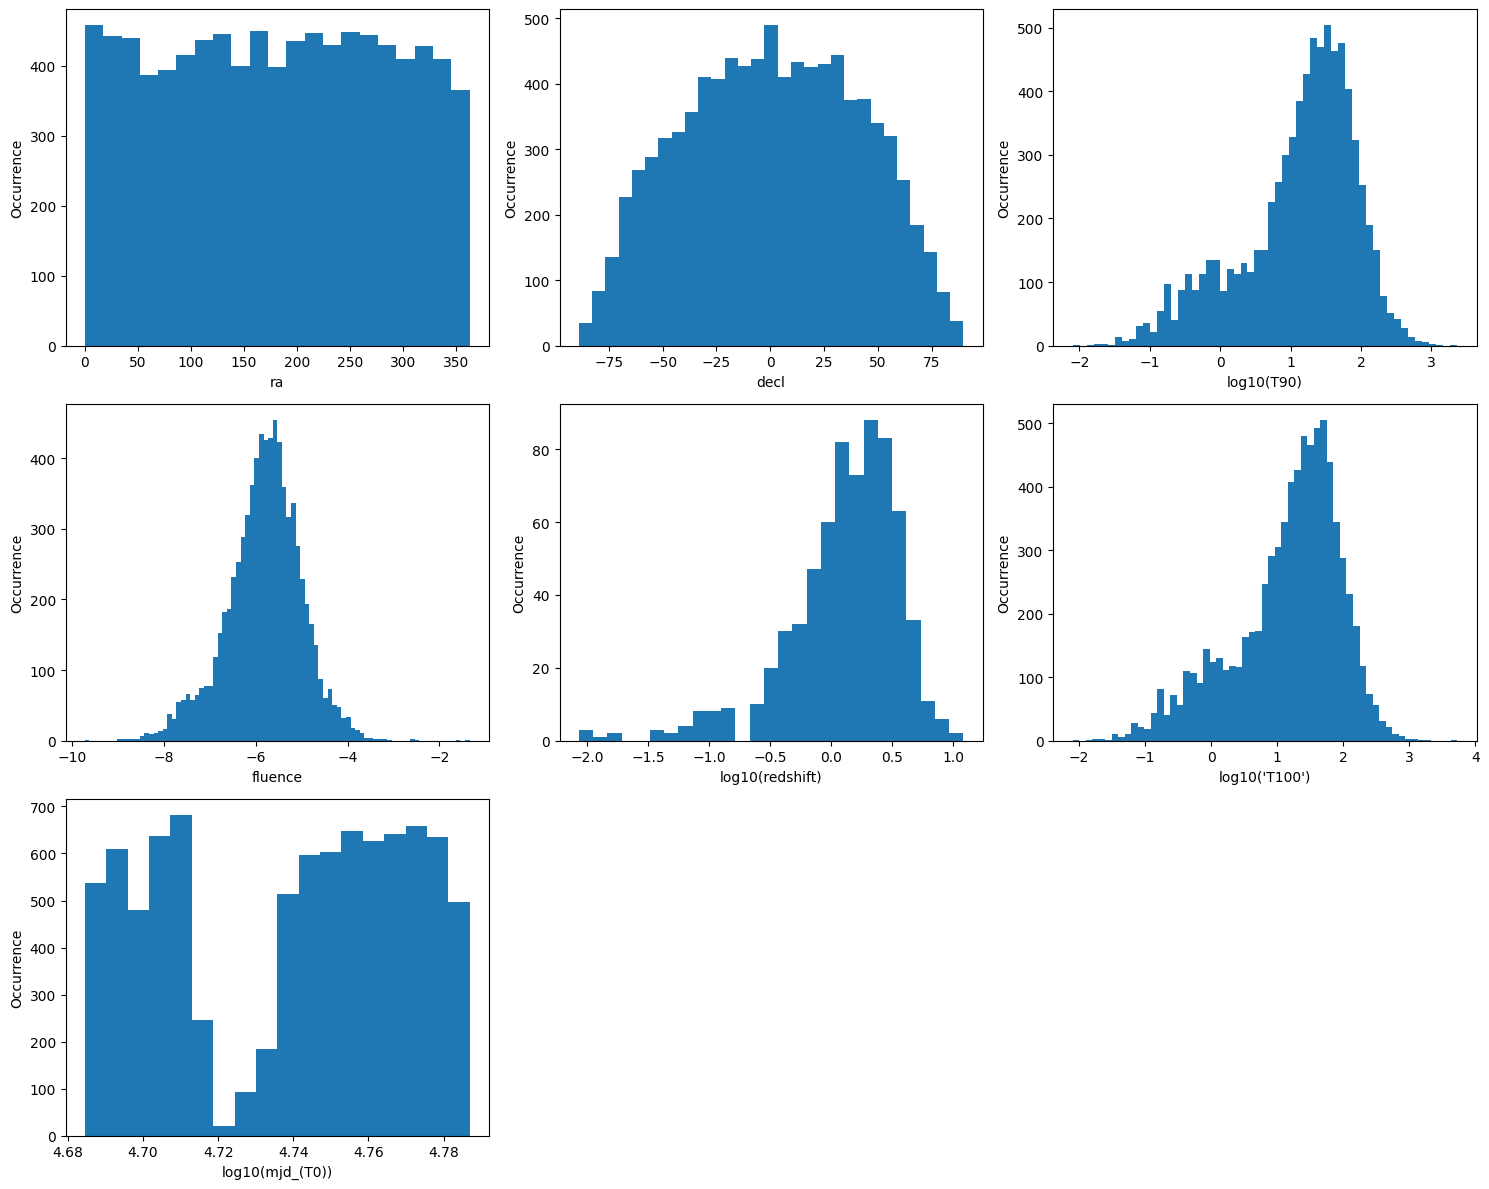

In [9]:
n_cols = 3  
n_rows = int(np.ceil(len(cols_to_numeric) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_to_numeric):
    ax = axes[i]
    data = df[col].replace([np.inf, -np.inf], np.nan).dropna()
    if col == 'fluence':
        data = np.log10(data[data > 0])
    if (data > 0).all():
        data = np.log10(data)
        label = f'log10({col})'
    else:
        label = col
    ax.set_xlabel(label)
    ax.set_ylabel('Occurrence')
    astropy.visualization.hist(data, bins="freedman", ax=ax)
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


Use only the T90 data to perform some clustering. Try MeanShift and KMeans to check if you get comparable results

The MeanShift algorithm found 2 clusters
[[31.69575063]
 [ 1.01738112]]
The KMeans algorithm found 2 clusters
[[ 0.91469766]
 [33.00580763]]
The boundary is found at 5.354997665732452


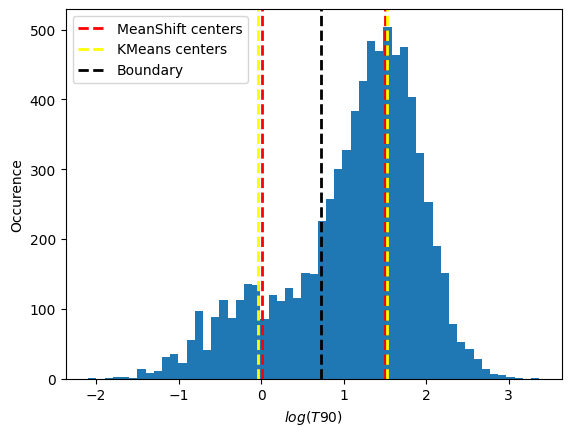

In [27]:
cols_to_keep = ['T90']
df_clean = df[cols_to_keep].copy()
df_clean['T90'] = np.log10(df_clean['T90'])
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
df_clean = df_clean.dropna()
fig, ax = plt.subplots()
plt.xlabel('$log(T90)$')
plt.ylabel('Occurence')
astropy.visualization.hist(df_clean['T90'], bins="freedman", ax = ax);

scaler = preprocessing.StandardScaler()
bandwidth = 0.45

ms = MeanShift(bandwidth=bandwidth,bin_seeding=True,cluster_all=True)
ms_labels = ms.fit_predict(scaler.fit_transform(df_clean))

print('The MeanShift algorithm found', len(ms.cluster_centers_), 'clusters')

centers = np.sort(scaler.inverse_transform(ms.cluster_centers_))
print(10**centers)
for i, c in enumerate(centers):
    ax.axvline(x=c, color='red', linestyle='--', linewidth=2, label='MeanShift centers' if i==1 else None)

from sklearn.cluster import KMeans

scaler = preprocessing.StandardScaler()

km = KMeans(n_clusters=2,n_init='auto')
km_labels = km.fit_predict(scaler.fit_transform(df_clean))

print('The KMeans algorithm found', len(km.cluster_centers_), 'clusters')

centers = np.sort(scaler.inverse_transform(km.cluster_centers_))
print(10**centers)
for i, c in enumerate(centers):
    ax.axvline(x=c, color='yellow', linestyle='--', linewidth=2, label='KMeans centers' if i==1 else None)
    
ax.legend()

labels = kmlabels
long = df_clean.iloc[np.where(labels==0)]
short = df_clean.iloc[np.where(labels==1)]
Boundary = np.mean([np.max(short),np.min(long)])
ax.axvline(x=Boundary, color='black', linestyle='--', linewidth=2, label='Boundary')
ax.legend()
print(f'The boundary is found at {10**Boundary}')

The 2 algo seem to find very similar results having the cluster centers in very similar location. Check how the clustering algorithm compare to each other with a confusion matrix

Text(0, 0.5, 'MeanShift-mean')

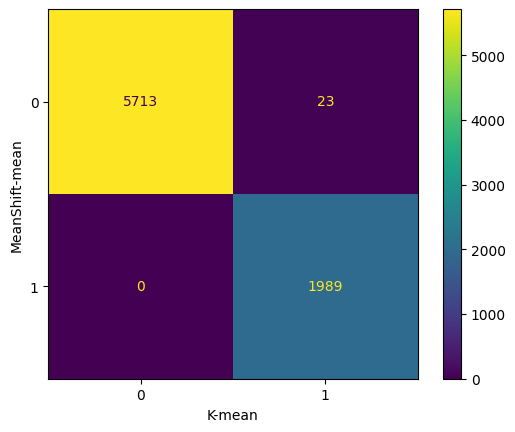

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(km.labels_, ms.labels_)
kmlabels = km.labels_
mslabels = ms.labels_

if cm[0,0] + cm[1,1] < cm[0,1] + cm[1,0]:
     kmlabels = 1 - kmlabels
    # cm = confusion_matrix(true_labels, labels)
    # print("Confusion Matrix (after relabeling):\n", cm)
cm = ConfusionMatrixDisplay.from_predictions(kmlabels, mslabels)
cm.ax_.set_xlabel('K-mean')
cm.ax_.set_ylabel('MeanShift-mean')

Let's look at correlation with fluence and t90

C:\Anaconda\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0, 0.5, '$\\log_{10}(fluence)$')

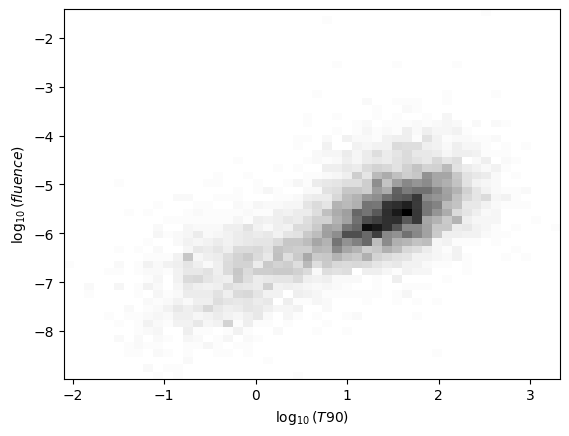

In [29]:
cols_to_keep = ['T90', 'fluence']
df_clean = df[cols_to_keep].copy()
df_clean['T90'] = np.log10(df_clean['T90'])
df_clean['fluence'] = np.log10(df_clean['fluence'])
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
df_clean = df_clean.dropna().reset_index(drop=True)

n_bins = 50
x = df_clean['T90'].values
y = df_clean['fluence'].values
x_edges = np.linspace(x.min(), x.max(), n_bins + 1)
y_edges = np.linspace(y.min(), y.max(), n_bins + 1)
H, xedges, yedges = np.histogram2d(x, y,  bins=[x_edges, y_edges])
plt.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
 extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
 cmap=plt.cm.binary)
plt.xlabel('$\log_{10}(T90)$')
plt.ylabel('$\log_{10}(fluence)$')

Seems that shorter GRB are harder to see probably also due to lower fluence making them harder to detect compared to long GRBs